# Project - E-commerce Sales & Customer Behaviour
## Phase 2 - Feature Engineering

**What this notebook does**
1. Loads `master_orders.csv` from Phase 1
2. Engineers RFM (Recency, Frequency, Monetary) features
3. Computes CLV (Customer Lifetime Value) estimates
4. Creates churn flags
5. Loads all tables into a local SQLite database
6. Verifies the database is ready for SQL queries

**Output: ** `ecommerce.db` - a SQLite database PowerBI and SQL notebooks will connect to

## 1. Imports and Configuration

In [37]:
# Import libararies
import pandas as pd
import numpy as np
import sqlite3
import os
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Ignore warnings, set theme for plots and dpi for images
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Paths
PROCESSED = "../data/processed/"
RAW = "../data/raw/"
DB_PATH = "../data/processed/ecommerce.db"

# Print success message if all libraries import correctly
print('All libraries imported successfully')
print(f'Database will be saved to: {DB_PATH:>50}')

All libraries imported successfully
Database will be saved to:                     ../data/processed/ecommerce.db


## 2. Load Master Table from Phase 1

In [38]:
# Read data from master_orders.csv file
master = pd.read_csv(PROCESSED+'master_orders.csv',
                     parse_dates = ['order_purchase_timestamp',
                                   'order_delivered_customer_date',
                                   'order_estimated_delivery_date']
                    )

# Print data shape, date range and unique customers 
print(f'Master table loaded: {master.shape[0]:,} rows x {master.shape[1]:,} columns')
print(f'Date range: {master["order_purchase_timestamp"].min().date()} -> {master["order_purchase_timestamp"].max().date()}')
print(f'Unique customers: {master["customer_unique_id"].nunique():,}')
master.head(5)

Master table loaded: 96,478 rows x 23 columns
Date range: 2016-09-15 -> 2018-08-29
Unique customers: 93,358


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,total_revenue,customer_unique_id,customer_state,customer_city,num_items,items_revenue,freight_value,category_en,review_score,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,38.71,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,1,29.99,8.72,housewares,4.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,141.46,af07308b275d755c9edb36a90c618231,BA,barreiras,1,118.70,22.76,perfumery,4.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,179.12,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,1,159.90,19.22,auto,5.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,72.20,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,1,45.00,27.20,pet_shop,5.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,28.62,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,1,19.90,8.72,stationery,5.0,credit_card


In [39]:
master.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_dow',
 'purchase_hour',
 'delivery_delay_days',
 'total_revenue',
 'customer_unique_id',
 'customer_state',
 'customer_city',
 'num_items',
 'items_revenue',
 'freight_value',
 'category_en',
 'review_score',
 'payment_type']

In [40]:
nulls = master.isnull().sum()
for col, count in nulls.items():
    pct = count / len(master) * 100
    print(f'  {col:<45} {count:>5,}  ({pct:.1f}%)')

  order_id                                          0  (0.0%)
  customer_id                                       0  (0.0%)
  order_status                                      0  (0.0%)
  order_purchase_timestamp                          0  (0.0%)
  order_approved_at                                14  (0.0%)
  order_delivered_carrier_date                      2  (0.0%)
  order_delivered_customer_date                     8  (0.0%)
  order_estimated_delivery_date                     0  (0.0%)
  purchase_year                                     0  (0.0%)
  purchase_month                                    0  (0.0%)
  purchase_dow                                      0  (0.0%)
  purchase_hour                                     0  (0.0%)
  delivery_delay_days                               8  (0.0%)
  total_revenue                                     1  (0.0%)
  customer_unique_id                                0  (0.0%)
  customer_state                                    0  (0.0%)
  custom

In [41]:
master.duplicated().sum()

0

## 3. RFM Feature Engineering

RFM is an industry standard customer segmentation framework used in e-commerce, banking, retail and telecom

| Letter | Meaning | Question it answers|
|--------|---------|--------------------|
|**R** - Recency | Days since last purchase | How recently did the customer buy? |
|**F** - Frequency | Number of orders | How often do they buy? |
|**M** - Monetary | Total spend | How much have they spent? |

Each metric is scored from 1 to 5 (5 being the best). The scores are combined into customer segments

In [42]:
# Reference date = 1 day after the last order in the dataset
# This is a standard practice - avoids giving a recency score of 0 to the most recent customer
REFERENCE_DATE = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'RFM reference date: {REFERENCE_DATE.date()}')

# Compute R, F, M for each unique customer
rfm = master.groupby('customer_unique_id').agg(
    last_purchase_date = ('order_purchase_timestamp', 'max'),    #latest order date
    frequency = ('order_id', 'nunique'),                    # unique orders
    monetary = ('total_revenue', 'sum')                     # total revenue 
    ).reset_index()

# Compute recency which is the number of days since last purchase
rfm['recency'] = (REFERENCE_DATE - rfm['last_purchase_date']).dt.days

# Display number of unqiue customers and rfm summary statistics
print(f'Unique customers: {rfm.shape[0]:,}')
print('RFM summary statistics: ')
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

RFM reference date: 2018-08-30
Unique customers: 93,358
RFM summary statistics: 
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    165.20
std      152.59       0.21    226.31
min        1.00       1.00      0.00
25%      114.00       1.00     63.05
50%      219.00       1.00    107.78
75%      346.00       1.00    182.56
max      714.00      15.00  13664.08


In [43]:
# Checking distribution of frequency
print('Frequency Distribution: ')
print(rfm['frequency'].value_counts().sort_index().head(10))

Frequency Distribution: 
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: frequency, dtype: int64


In [44]:
# Score recency and monetary metric from 1 to 5 using quintiles
# Recency us reversed because less days means more recent which should give a better score
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

# Define custom function for frequency scores since 97% customers have frequency=1
def score_frequency(freq):
    if freq==1:
        return 1
    elif freq==2:
        return 2
    elif freq==3:
        return 3
    elif freq==4:
        return 4
    else:
        return 5
#Compue frequency score based custom function
rfm['f_score'] = rfm['frequency'].apply(score_frequency)

# Combined RFM score (eg. 4-5-3)
rfm['rfm_score'] = rfm['r_score'].astype(str) + '-' + rfm['f_score'].astype(str) + '-' + rfm['m_score'].astype(str)

# Numeric combined score (R - 40%, F - 30%, M - 30%)
rfm['rfm_combined'] = (rfm['r_score']*0.4 + rfm['f_score']*0.3 + rfm['m_score']*0.3).round(2)

# Display results
print('Samples of RFM scores: ')
rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_combined']].head(10)

Samples of RFM scores: 


,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_combined
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,4-1-4,3.1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,4-1-1,2.2
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,1-1-2,1.3
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,2-1-1,1.4
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,2-1-4,2.3
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4,1,4,4-1-4,3.1
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4,1,1,4-1-1,2.2
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,3,1,5,3-1-5,3.0
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,1,4,1-1-4,1.9
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,4,1,3,4-1-3,2.8


In [45]:
# Assign customer segments from industry-standard RFM segmentation model based on combined RFM score 
def assign_segment(row):
    r,f,m = row['r_score'], row['f_score'], row['m_score']
    if r>=4 and f>=4 and m>=4:
        return 'Champions'                  # bought recently, buys often, spends the most
    elif r>=3 and f>=3:
        return 'Loyal Customers'            # decent recency, regular buying
    elif r>=4 and f<=2:
        return 'New Customers'              # bought recently but only once or twice
    elif r>=3 and f<=2 and m>=3:
        return 'Potential Loyalists'        # recent, low frequency, decent spending
    elif r==3 and f==3:
        return 'Needs Attention'            # RFM is average, at risk of disengaging
    elif r<=2 and f>=3 and m>=3:
        return 'At Risk'                    # Used to buy often, but haven't recently
    elif r<=2 and f>=4:
        return 'Cannot Lose Them'           # Previously frequent, now inactive - urgent
    elif r==1 and f==1:
        return 'Lost'                       # Bought once, long ago, never returned
    else:
        return 'Hibernating'                # Low recency, low engagement
    
# Apply segment assigning function to the RFM dataframe
rfm['customer_segment'] = rfm.apply(assign_segment, axis=1)

segmentation_summary = rfm.groupby('customer_segment').agg(
    count = ('customer_unique_id', 'count'),
    avg_recency = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary = ('monetary', 'mean')
).round(2).sort_values('count', ascending=False)

print('Customer Segmentation breakdown: ')
print(segmentation_summary)

Customer Segmentation breakdown: 
                     count  avg_recency  avg_frequency  avg_monetary
customer_segment                                                    
New Customers        37311        90.58           1.03        168.18
Hibernating          26499       291.07           1.04        136.79
Lost                 18204       473.60           1.00        159.92
Potential Loyalists  11118       220.80           1.05        224.50
Loyal Customers        126       128.24           3.13        457.32
At Risk                 66       383.62           3.14        441.72
Champions               33        85.97           4.94        866.52
Cannot Lose Them         1       602.00           4.00         73.48


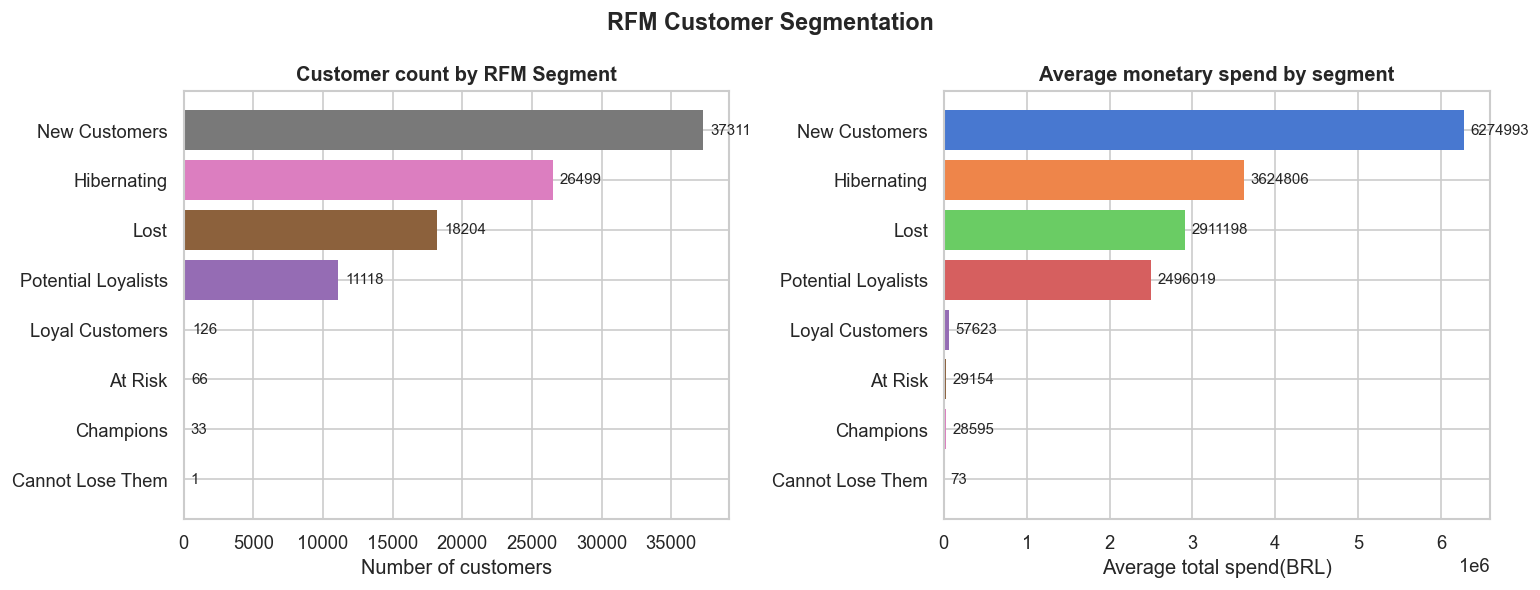

Figure saved


In [46]:
# Visualise customer segmentation distribution
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Segment frequency count
seg_count = rfm.customer_segment.value_counts()
colors = sns.color_palette('muted', len(seg_count))
bars = axes[0].barh(seg_count.index[::-1], seg_count.values[::-1], 
                    color=sns.color_palette('muted', len(seg_count)), 
                    edgecolor='none')
axes[0].bar_label(bars, fmt='%.0f', padding=4, fontsize=9)
axes[0].set_title('Customer count by RFM Segment', fontweight='bold')
axes[0].set_xlabel('Number of customers')

# Average monetary spend per segment
seg_mon = rfm.groupby('customer_segment')['monetary'].sum().sort_values(ascending=False)
bars2 = axes[1].barh(seg_mon.index[::-1], seg_mon.values[::-1], 
                     color=sns.color_palette('muted', len(seg_mon))[::-1],
                     edgecolor='none')
axes[1].bar_label(bars2, fmt='%.0f', padding=4, fontsize=9)
axes[1].set_title('Average monetary spend by segment', fontweight='bold')
axes[1].set_xlabel('Average total spend(BRL)')

plt.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED+'plot_rfm_segments.png', bbox_inches='tight')
plt.show()
print('Figure saved')

## 4. Customer Lifetime Value (CLV)

CLV estimates how much revenue a customer will generate over their entire relationship with the business.

**Formula used (simplified historical CLV):**
> CLV = Average Order Value x Purchase Frequency x Customer Lifepsan 

In [47]:
# per-customer metrics required to compute components of the CLV formula
customer_orders = master.groupby('customer_unique_id').agg(
    total_spend = ('total_revenue', 'sum'),
    order_count = ('order_id', 'nunique'),
    first_order_date = ('order_purchase_timestamp', 'min'),
    last_order_date = ('order_purchase_timestamp', 'max'),
    avg_review = ('review_score', 'mean')
).reset_index()

#Average order value per customer
customer_orders['average_order_value'] = customer_orders['total_spend'] / customer_orders['order_count']

# Customer lifespan in days (first to last order)
customer_orders['lifespan_days'] = (customer_orders['last_order_date'] 
                                    - customer_orders['first_order_date']).dt.days.clip(lower=1)

# Purchase rate or frequency = orders per day
customer_orders['purchase_rate'] = customer_orders['order_count'] / customer_orders['lifespan_days']

# Historical CLV = Total amount spent thus far (already observed)
# Prjected CLV = Average order value x expected orders in next year
# Assuming average lifespan of 365 days for all customers (standard assumption without churn model)
customer_orders['projected_clv'] = (customer_orders['average_order_value']*
                                    customer_orders['purchase_rate']*365).round(2)

print('CLV computed for all customers')
print(f'Averge historical CLV:    R${customer_orders["total_spend"].mean():,.2f}')
print(f'Average projected CLV:    R${customer_orders["projected_clv"].mean():,.2f}')
print(f'Top 10% CLV threshold:    R${customer_orders["total_spend"].quantile(0.9):,.2f}')

#CLV tier labels
customer_orders['clv_tier'] = pd.qcut(
    customer_orders['total_spend'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Premium']
)

customer_orders.head(10)

CLV computed for all customers
Averge historical CLV:    R$165.20
Average projected CLV:    R$57,962.39
Top 10% CLV threshold:    R$318.07


,customer_unique_id,total_spend,order_count,first_order_date,last_order_date,avg_review,average_order_value,lifespan_days,purchase_rate,projected_clv,clv_tier
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,2018-05-10 10:56:27,2018-05-10 10:56:27,5.0,141.90,1,1.0,51793.50,High
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,2018-05-07 11:11:27,2018-05-07 11:11:27,4.0,27.19,1,1.0,9924.35,Low
2,0000f46a3911fa3c0805444483337064,86.22,1,2017-03-10 21:05:03,2017-03-10 21:05:03,3.0,86.22,1,1.0,31470.30,Medium
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,2017-10-12 20:29:41,2017-10-12 20:29:41,4.0,43.62,1,1.0,15921.30,Low
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,2017-11-14 19:45:42,2017-11-14 19:45:42,5.0,196.89,1,1.0,71864.85,Premium
5,0004bd2a26a76fe21f786e4fbd80607f,166.98,1,2018-04-05 19:33:16,2018-04-05 19:33:16,4.0,166.98,1,1.0,60947.70,High
6,00050ab1314c0e55a6ca13cf7181fecf,35.38,1,2018-04-20 12:57:23,2018-04-20 12:57:23,4.0,35.38,1,1.0,12913.70,Low
7,00053a61a98854899e70ed204dd4bafe,419.18,1,2018-02-28 11:15:41,2018-02-28 11:15:41,1.0,419.18,1,1.0,153000.70,Premium
8,0005e1862207bf6ccc02e4228effd9a0,150.12,1,2017-03-04 23:32:12,2017-03-04 23:32:12,4.0,150.12,1,1.0,54793.80,High
9,0005ef4cd20d2893f0d9fbd94d3c0d97,129.76,1,2018-03-12 15:22:12,2018-03-12 15:22:12,1.0,129.76,1,1.0,47362.40,High


## 5. Churn Flag

A customer is flagged as **churned** if they have not placed an order in the last 90 days relative to the reference date.

In [48]:
# Define number of days for churn threshold
CHURN_THRESHOLD_DAYS = 90

# Convert data type for last order date to DateTime data type
customer_orders['last_order_date'] = pd.to_datetime(customer_orders['last_order_date'])
# Calculate number of days since last order
customer_orders['days_since_last_order'] = (REFERENCE_DATE - customer_orders['last_order_date']).dt.days

# Create a column for customers who are churned
customer_orders['is_churned'] = customer_orders['days_since_last_order'] > CHURN_THRESHOLD_DAYS
# Calculate churn rate 
churn_rate = customer_orders['is_churned'].mean()*100

# Display churn threshold, churned and active customers, and churn rate
print(f'Churn threshold   -  {CHURN_THRESHOLD_DAYS} days since last order')
print(f'Churned customers -  {customer_orders["is_churned"].sum():,}')
print(f'Acitve customers  -  {(~customer_orders["is_churned"]).sum():,}')
print(f'Churn rate        -  {churn_rate:.1f}%')

# Churn by CLV tier - high value churned customers need urgent win-back
churn_by_clv = customer_orders.groupby('clv_tier')['is_churned'].mean()*100
print('\nChurn rate by CLV tiers: ')
for tier, rate in churn_by_clv.items():
    priority = 'WIN-BACK PRIORITY' if tier in ['Premium', 'High'] and rate>50 else ''
    print(f' {tier:<10} {rate:.1f}%  {priority}')

Churn threshold   -  90 days since last order
Churned customers -  74,899
Acitve customers  -  18,459
Churn rate        -  80.2%

Churn rate by CLV tiers: 
 Low        80.3%  
 Medium     81.2%  
 High       79.7%  WIN-BACK PRIORITY
 Premium    79.8%  WIN-BACK PRIORITY


## 6. Build Final Analytical Tables

Merge all engineered features into the following 2 clean tables:
- `dim_customers` - one row per customer with all RFM, CLV and churn attributes
- `fact_orders` - enriched order-level fact table for the dashboard~

In [55]:
# Define customer dimension table that contains all computed attributes
dim_customers = (
    customer_orders
    .merge(
        rfm[['customer_unique_id', 'r_score', 'f_score', 
             'm_score', 'rfm_score', 'rfm_combined', 'customer_segment']],
        on='customer_unique_id', how='left'
    )
    .merge(
        master[['customer_unique_id','customer_state','review_score',
                'customer_city']].drop_duplicates('customer_unique_id'),
        on='customer_unique_id', how='left'
    )
)

# Define order-level fact table
fact_orders = master[['order_id', 'customer_unique_id',
                      'order_purchase_timestamp', 'order_delivered_customer_date',
                      'order_estimated_delivery_date', 'order_status', 'total_revenue',
                      'num_items', 'items_revenue', 'freight_value', 'review_score',
                      'payment_type', 'customer_state', 'customer_city','category_en',
                      'delivery_delay_days']].copy()

# Derive date features for PowerBI dashboard
fact_orders['purchase_year']       = fact_orders['order_purchase_timestamp'].dt.year
fact_orders['purchase_month']      = fact_orders['order_purchase_timestamp'].dt.month
fact_orders['purchase_month_name'] = fact_orders['order_purchase_timestamp'].dt.strftime('%B')
fact_orders['purchase_quarter']    = fact_orders['order_purchase_timestamp'].dt.quarter
fact_orders['is_weekend']          = fact_orders['order_purchase_timestamp'].dt.weekday >= 5
fact_orders['is_late']             = fact_orders['delivery_delay_days'] > 0

# Display data from customer dimension and order-level fact tables
print(f'dim_customers : {dim_customers.shape[0]:,} rows x {dim_customers.shape[1]} cols')
print(f'fact_orders   : {fact_orders.shape[0]:,} rows x {fact_orders.shape[1]} cols')
print('\nSegment distribution in dim_customers:')
print(dim_customers['customer_segment'].value_counts())

dim_customers : 93,358 rows x 22 cols
fact_orders   : 96,478 rows x 22 cols

Segment distribution in dim_customers:
New Customers          37311
Hibernating            26499
Lost                   18204
Potential Loyalists    11118
Loyal Customers          126
At Risk                   66
Champions                 33
Cannot Lose Them           1
Name: customer_segment, dtype: int64


## 7. Load All Tables into SQLite

In [56]:
# Load original raw CSVs 
orders        = pd.read_csv(RAW + 'olist_orders_dataset.csv')
order_items   = pd.read_csv(RAW + 'olist_order_items_dataset.csv')
order_payments= pd.read_csv(RAW + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(RAW + 'olist_order_reviews_dataset.csv')
customers     = pd.read_csv(RAW + 'olist_customers_dataset.csv')
products      = pd.read_csv(RAW + 'olist_products_dataset.csv')
sellers       = pd.read_csv(RAW + 'olist_sellers_dataset.csv')
category_trans= pd.read_csv(RAW + 'product_category_name_translation.csv')

# Connect to SQLite
conn = sqlite3.connect(DB_PATH)

# Tables to load: (DataFrame, table_name)
tables = [
    (orders,          'raw_orders'),
    (order_items,     'raw_order_items'),
    (order_payments,  'raw_order_payments'),
    (order_reviews,   'raw_order_reviews'),
    (customers,       'raw_customers'),
    (products,        'raw_products'),
    (sellers,         'raw_sellers'),
    (category_trans,  'raw_category_translation'),
    (fact_orders,     'fact_orders'),
    (dim_customers,   'dim_customers'),
    (rfm,             'rfm_scores'),
]

# Display table dimensions for all tables in the ecommerce.db
for df, name in tables:
    df.to_sql(name, conn, if_exists='replace', index=False)
    row_count = pd.read_sql(f'SELECT COUNT(*) as n FROM {name}', conn)['n'][0]
    print(f'  {name:<35} {row_count:>8,} rows')

# Close the connection
conn.close()

# Compute size of the file in MB
db_size_mb = os.path.getsize(DB_PATH) / (1024 * 1024)

# Print location of the saved file and file size
print(f'\nDatabase saved: {DB_PATH}')
print(f'Database size : {db_size_mb:.1f} MB')

  raw_orders                            99,441 rows
  raw_order_items                      112,650 rows
  raw_order_payments                   103,886 rows
  raw_order_reviews                     99,224 rows
  raw_customers                         99,441 rows
  raw_products                          32,951 rows
  raw_sellers                            3,095 rows
  raw_category_translation                  71 rows
  fact_orders                           96,478 rows
  dim_customers                         93,358 rows
  rfm_scores                            93,358 rows

Database saved: ../data/processed/ecommerce.db
Database size : 111.8 MB


## 8. Database verification

In [58]:
# Connect to database
conn = sqlite3.connect(DB_PATH)

# TEST QUERY 1:  list all tables#
print('Tables in ecommerce.db:')
tables_in_db = pd.read_sql(
    "SELECT name, type FROM sqlite_master WHERE type= 'table' ORDER BY name",
    conn
)
print(tables_in_db.to_string(index=False))


# TEST QUERY 2: Top 5 customers by total spend
print('\nTop 5 customer by total spend: ')
top_customers = pd.read_sql(
    """
    SELECT
        customer_unique_id,
        customer_segment,
        clv_tier,
        ROUND(total_spend,2) AS total_spend_brl,
        order_count,
        ROUND(average_order_value,2) AS avg_order_value_brl
    FROM 
        dim_customers
    ORDER BY 
        total_spend DESC
    LIMIT 5
    """, conn)
print(top_customers.to_string(index=False))

# TEST QUERY 3: Customer Segment summary
print('\nRFM Segment summary: ')
seg_sql = pd.read_sql(
    """
    SELECT
        customer_segment,
        COUNT(*)                    AS customer_count,
        ROUND(AVG(total_spend),2)   AS avg_spend,
        ROUND(AVG(review_score),2)  AS avg_review_score
    FROM 
        dim_customers
    GROUP BY
        customer_segment
    ORDER BY
        customer_count DESC
    """, conn)
print(seg_sql.to_string(index=False))

# Close database connection
conn.close()

# Print verification testing success message
print('\nDatabase verification complete')

Tables in ecommerce.db:
                    name  type
           dim_customers table
             fact_orders table
raw_category_translation table
           raw_customers table
         raw_order_items table
      raw_order_payments table
       raw_order_reviews table
              raw_orders table
            raw_products table
             raw_sellers table
              rfm_scores table

Top 5 customer by total spend: 
              customer_unique_id customer_segment clv_tier  total_spend_brl  order_count  avg_order_value_brl
0a0a92112bd4c708ca5fde585afaa872      Hibernating  Premium         13664.08            1             13664.08
da122df9eeddfedc1dc1f5349a1a690c      Hibernating  Premium          7571.63            2              3785.82
763c8b1c9c68a0229c42c9fc6f662b93    New Customers  Premium          7274.88            1              7274.88
dc4802a71eae9be1dd28f5d788ceb526             Lost  Premium          6929.31            1              6929.31
459bef486812aa25204be

## 9. Export CSVs for Power BI

In [60]:
# Export the two main analytical tables as CSVs for Power BI import
fact_orders.to_csv(PROCESSED + 'fact_orders.csv', index=False)
dim_customers.to_csv(PROCESSED + 'dim_customers.csv', index=False)
rfm.to_csv(PROCESSED + 'rfm_scores.csv', index=False)

print('CSVs exported for Power BI:')
for fname in ['fact_orders.csv', 'dim_customers.csv', 'rfm_scores.csv']:
    size_kb = os.path.getsize(PROCESSED + fname) / 1024
    print(f'  {fname:<30} {size_kb:.0f} KB')

CSVs exported for Power BI:
  fact_orders.csv                21126 KB
  dim_customers.csv              15462 KB
  rfm_scores.csv                 8632 KB
